In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB, CategoricalNB, BernoulliNB
import time
from sklearn.metrics import log_loss
from sklearn.metrics import recall_score

In [15]:
# Problem 1
df1 = pd.read_csv('HealthProb1.csv')

# get explanatory and response variables separate
X1 = df1.drop(columns=['HealthCondition'])
y1 = df1['HealthCondition']

# 3.1, first split into training and validation
X1_train, X1_val, y1_train, y1_val = train_test_split(X1, y1, test_size=0.2, random_state = 5104)
df1_train = X1_train.copy()
df1_train['HealthCondition'] = y1_train
df1_val = X1_val.copy()
df1_val['HealthCondition'] = y1_val

#df1_train.to_csv('Prob1_train.csv', index=False)
#df1_val.to_csv('Prob1_val.csv', index=False)

In [16]:
# PART C NEW CODE MUTUAL INFORMATION FILTER FEATURE SELECTION
from sklearn.feature_selection import mutual_info_classif, SelectKBest

print(X1_train.shape[1])
feature_filter = SelectKBest(mutual_info_classif, k=X1_train.shape[1]//2).fit(X1_train, y1_train)
selected_cols = X1_train.columns[feature_filter.get_support()]
X1_train = pd.DataFrame(feature_filter.transform(X1_train), columns=selected_cols)
X1_val = pd.DataFrame(feature_filter.transform(X1_val), columns=selected_cols)


print(X1_train.head())
print(X1_val.head())
X1_train.to_csv('Prob1_train_red.csv', index=False)
X1_val.to_csv('Prob1_val_red.csv', index=False)

17
   CholCheck  BMI  PhysActivity  Veggies  AnyHealthcare  GenHlth  DiffWalk  \
0          1   27             1        0              1        2         0   
1          1   34             1        1              1        3         0   
2          1   27             0        1              1        2         0   
3          1   36             1        1              1        3         0   
4          1   31             1        1              1        3         0   

   Age  
0    8  
1    8  
2    8  
3   13  
4    7  
   CholCheck  BMI  PhysActivity  Veggies  AnyHealthcare  GenHlth  DiffWalk  \
0          1   27             1        1              1        2         0   
1          1   51             1        0              1        2         0   
2          1   24             1        1              1        1         0   
3          1   17             0        0              1        4         1   
4          1   25             1        1              1        2         0   

   Ag

for alpha value: 0, average recall metric measure value among the k=5 folds was 0.8204254220708451
for alpha value: 0.005, average recall metric measure value among the k=5 folds was 0.9052725189995
for alpha value: 0.01, average recall metric measure value among the k=5 folds was 0.8290184732489276
for alpha value: 0.015, average recall metric measure value among the k=5 folds was 0.8290184732489276
for alpha value: 0.02, average recall metric measure value among the k=5 folds was 0.8290184732489276
[0.8204254220708451, 0.9052725189995, 0.8290184732489276, 0.8290184732489276, 0.8290184732489276]
Best hyperparameter value was ccp_alpha = 0.005 with performance metric value of 0.9052725189995
Runtime: 9.514945983886719


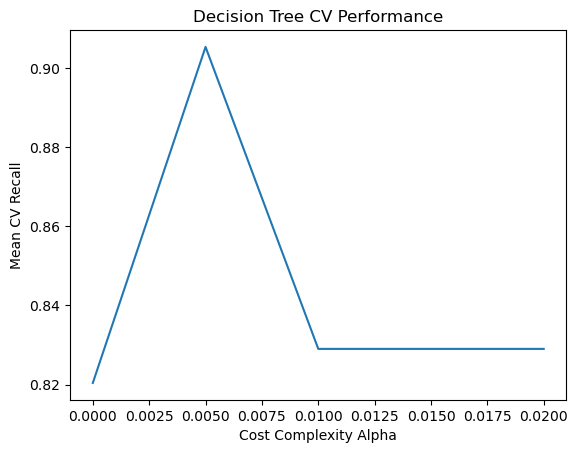

In [17]:
# Problem 1 - Decision Tree

ccp_alpha_vals = [0, 0.005, 0.010, 0.015, 0.020]

startTime = time.time()
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5104)
cv_means = []

for alpha in ccp_alpha_vals:
    dtc1 = DecisionTreeClassifier(criterion = 'gini', ccp_alpha=alpha, random_state=5104)
    scores = cross_val_score(dtc1, X1_train, y1_train, cv=kf, scoring='recall')
    # using recall as performance metric for each model because the cost of a false negative is higher than overall accuracy or a false positive
    # since false negative would mean potentially leaving a patient at risk of a health condition alone/untreated
    cv_means.append(np.mean(scores))
    print('for alpha value: ' + str(alpha)+', average recall metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was ccp_alpha = ' + str(ccp_alpha_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(ccp_alpha_vals, cv_means)
plt.xlabel('Cost Complexity Alpha')
plt.ylabel('Mean CV Recall')
plt.title('Decision Tree CV Performance')
plt.show()

folds done
for alpha value: 1e-05, average negative logloss metric measure value among the k=5 folds was -0.5178642584516815
for alpha value: 0.0001, average negative logloss metric measure value among the k=5 folds was -0.5180883119125848
for alpha value: 0.001, average negative logloss metric measure value among the k=5 folds was -0.5177462205005037
for alpha value: 0.01, average negative logloss metric measure value among the k=5 folds was -0.5177128319516122
for alpha value: 0.1, average negative logloss metric measure value among the k=5 folds was -0.5177551716252893
[-0.5178642584516815, -0.5180883119125848, -0.5177462205005037, -0.5177128319516122, -0.5177551716252893]
Best hyperparameter value was alpha = 0.01 with performance metric value of -0.5177128319516122
Runtime: 217.00147366523743


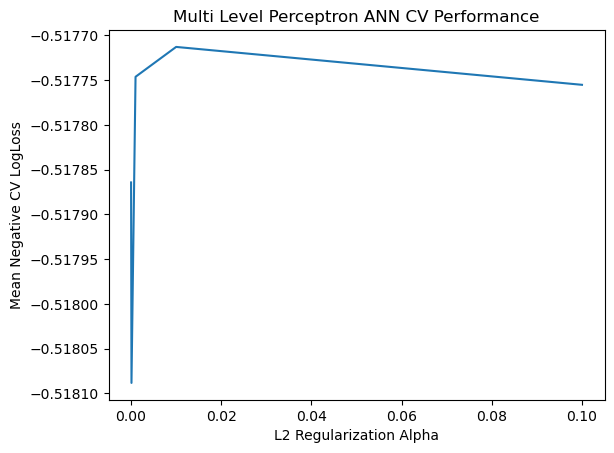

In [18]:
# Problem 1 - ANN

alpha_vals =  [0.00001, 0.0001, 0.001, 0.01, 0.1]
startTime = time.time()
kf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5103)
cv_means = []
print('folds done')

for alpha in alpha_vals:
    ann1 = MLPClassifier(activation = 'relu', alpha=alpha, random_state=5104, max_iter = 200)
    scores = cross_val_score(ann1, X1_train, y1_train, cv=kf, scoring='neg_log_loss')
    # using logloss/cross entropy loss as performance metric
    cv_means.append(np.mean(scores))
    print('for alpha value: ' + str(alpha)+', average negative logloss metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was alpha = ' + str(alpha_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(alpha_vals, cv_means)
plt.xlabel('L2 Regularization Alpha')
plt.ylabel('Mean Negative CV LogLoss')
plt.title('Multi Level Perceptron ANN CV Performance')
plt.show()

for smoothing alpha value: 0.0001, average accuracy metric measure value among the k=5 folds was 0.7087127508655119
for smoothing alpha value: 0.001, average accuracy metric measure value among the k=5 folds was 0.7087127508655119
for smoothing alpha value: 0.01, average accuracy metric measure value among the k=5 folds was 0.7087127508655119
for smoothing alpha value: 0.1, average accuracy metric measure value among the k=5 folds was 0.7087127508655119
for smoothing alpha value: 0.5, average accuracy metric measure value among the k=5 folds was 0.7087078234221159
for smoothing alpha value: 1, average accuracy metric measure value among the k=5 folds was 0.7087078234221159
for smoothing alpha value: 5, average accuracy metric measure value among the k=5 folds was 0.7085747792939854
Best hyperparameter value was alpha = 0.0001 with performance metric value of 0.7087127508655119
Runtime: 2.1591176986694336


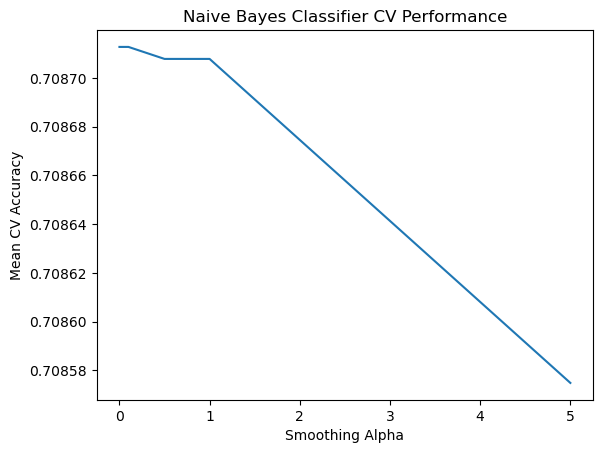

In [20]:
# Problem 1 - Naive Bayes Classifier

# remaining vars after dimension reduction: CholCheck  BMI  PhysActivity  Veggies  AnyHealthcare  GenHlth  DiffWalk  Age

smoothing_alpha_vals =  [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5]

binary_vars = ['CholCheck', 'PhysActivity', 'Veggies', 'AnyHealthcare', 'DiffWalk']

cat_vars = ['Age', 'GenHlth']

num_vars = ['BMI']

X1_train_cat = X1_train[cat_vars]
X1_train_num = X1_train[num_vars]
X1_train_bin = X1_train[binary_vars]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5103)

cv_means = []
startTime = time.time()

for alpha in smoothing_alpha_vals:
    fold_scores = []
    
    for train_idx, test_idx in kf.split(X1_train, y1_train):

        # manually doing k folds bc idk how to use cross_val_score when combining results from 3 different estimators
        # split into separate training and test folds for cat, num and bin variables
        X_cat_tr = X1_train_cat.iloc[train_idx]
        X_cat_te = X1_train_cat.iloc[test_idx]
        
        X_num_tr = X1_train_num.iloc[train_idx]
        X_num_te = X1_train_num.iloc[test_idx]
        
        X_bin_tr = X1_train_bin.iloc[train_idx]
        X_bin_te = X1_train_bin.iloc[test_idx]
        
        y_tr = y1_train.iloc[train_idx]
        y_te = y1_train.iloc[test_idx]
        
        # models
        nbc = CategoricalNB(alpha=alpha)
        nbm = MultinomialNB(alpha=alpha)
        nbb = BernoulliNB(alpha=alpha)
        
        nbc.fit(X_cat_tr, y_tr)
        nbm.fit(X_num_tr, y_tr)
        nbb.fit(X_bin_tr, y_tr)
        
        # Use log probs in order to stop vals from getting to small at first
        log_prob_cat = nbc.predict_log_proba(X_cat_te)
        log_prob_num = nbm.predict_log_proba(X_num_te)
        log_prob_bin = nbb.predict_log_proba(X_bin_te)
        log_probs = log_prob_cat + log_prob_num + log_prob_bin

        # get performance metrics
        y_pred = np.argmax(log_probs, axis=1)
        acc = accuracy_score(y_te, y_pred)
        fold_scores.append(acc)
    
    mean_score = np.mean(fold_scores)
    cv_means.append(mean_score)
    
    print('for smoothing alpha value: ' + str(alpha)+', average accuracy metric measure value among the k=5 folds was '+str(mean_score))


endTime = time.time()
runTime = endTime - startTime

best_index = np.argmax(cv_means)

print('Best hyperparameter value was alpha = ' + str(smoothing_alpha_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(smoothing_alpha_vals, cv_means)
plt.xlabel('Smoothing Alpha')
plt.ylabel('Mean CV Accuracy')
plt.title('Naive Bayes Classifier CV Performance')
plt.show()

folds done
for number of trees: 25, average accuracy metric measure value among the k=5 folds was 0.7342518192795281
for number of trees: 50, average accuracy metric measure value among the k=5 folds was 0.7353900678091141
for number of trees: 100, average accuracy metric measure value among the k=5 folds was 0.7358926715273604
for number of trees: 200, average accuracy metric measure value among the k=5 folds was 0.7361636810355414
for number of trees: 300, average accuracy metric measure value among the k=5 folds was 0.7362425208582863
[0.7342518192795281, 0.7353900678091141, 0.7358926715273604, 0.7361636810355414, 0.7362425208582863]
Best hyperparameter value was number of trees = 300 with performance metric value of 0.7362425208582863
Runtime: 168.51967215538025


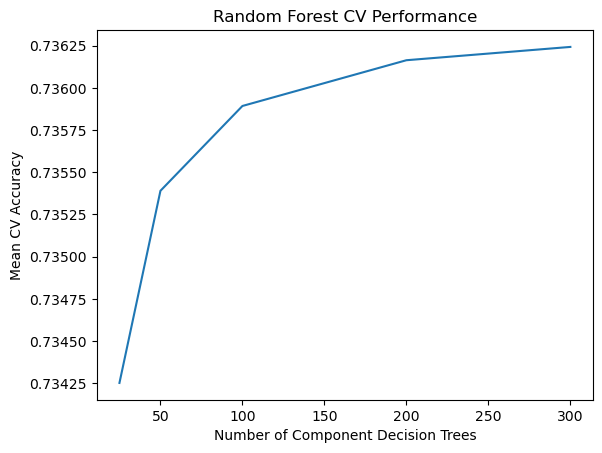

In [22]:
# Problem 1 - Random Forest

num_trees_vals = [25, 50, 100, 200, 300]
startTime = time.time()
kf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5103)
cv_means = []
print('folds done')

for tree_num in num_trees_vals:
    rfc1 = RandomForestClassifier(criterion = 'gini', n_estimators = tree_num)
    scores = cross_val_score(rfc1, X1_train, y1_train, cv=kf, scoring='accuracy')
    # using recall as performance metric (same reasoning as that for decision tree)
    cv_means.append(np.mean(scores))
    print('for number of trees: ' + str(tree_num)+', average accuracy metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was number of trees = ' + str(num_trees_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(num_trees_vals, cv_means)
plt.xlabel('Number of Component Decision Trees')
plt.ylabel('Mean CV Accuracy')
plt.title('Random Forest CV Performance')
plt.show()

In [23]:
# Problem 1 - FINAL MODEL TRAINING/TESTING

best_ccp_alpha = 0.005

startTime = time.time()
print("DECISION TREE:")

dtc2 = DecisionTreeClassifier(criterion = 'gini', ccp_alpha=best_ccp_alpha, random_state=5104)
dtc2.fit(X2_train, y2_train)
y2_train_pred = dtc2.predict(X2_train)
train_acc = accuracy_score(y2_train_pred, y2_train)

endTime = time.time()
runTime = endTime-startTime
print("training runtime was "+str(runTime))
print("training performance was accuracy = "+str(train_acc))

startTime = time.time()
y2_val_pred = dtc2.predict(X2_val)
val_acc = accuracy_score(y2_val_pred, y2_val)
endTime = time.time()
runTime = endTime-startTime

print("testing runtime was "+str(runTime))
print("testing performance was accuracy = "+str(val_acc))

best_ann_alpha = 0.01

startTime = time.time()
print("ANN:")

ann2 = MLPClassifier(activation = 'relu', alpha=best_ann_alpha, random_state=5104, max_iter = 200)
ann2.fit(X2_train, y2_train)
y2_train_proba = ann2.predict_proba(X2_train)
train_logloss = log_loss(y2_train, y2_train_proba)

endTime = time.time()
runTime = endTime-startTime
print("training runtime was "+str(runTime))
print("training performance was logloss = "+str(train_logloss))

startTime = time.time()
y2_val_proba = ann2.predict_proba(X2_val)
val_logloss = log_loss(y2_val, y2_val_proba)

endTime = time.time()
runTime = endTime-startTime
print("testing runtime was "+str(runTime))
print("testing performance was logloss = "+str(val_logloss))


best_smoothing_alpha = 0.0001

startTime = time.time()
print("Naive Bayes Classifier:")
# remaining vars after dimension reduction: CholCheck  BMI  PhysActivity  GenHlth  PhysHlth  DiffWalk  Age  Income

binary_vars = ['CholCheck', 'PhysActivity', 'DiffWalk']

cat_vars = ['Age', 'GenHlth', 'Income']

num_vars = ['BMI', 'PhysHlth']

X2_train_cat = X2_train[cat_vars]
X2_train_num = X2_train[num_vars]
X2_train_bin = X2_train[binary_vars]

nbc = CategoricalNB(alpha=best_smoothing_alpha)
nbm = MultinomialNB(alpha=best_smoothing_alpha)
nbb = BernoulliNB(alpha=best_smoothing_alpha)
        
nbc.fit(X2_train_cat, y2_train)
nbm.fit(X2_train_num, y2_train)
nbb.fit(X2_train_bin, y2_train)
        
# Use log probs in order to stop vals from getting to small at first
log_prob_cat = nbc.predict_log_proba(X2_train_cat)
log_prob_num = nbm.predict_log_proba(X2_train_num)
log_prob_bin = nbb.predict_log_proba(X2_train_bin)
log_probs = log_prob_cat + log_prob_num + log_prob_bin

# get performance metrics
y2_train_pred = np.argmax(log_probs, axis=1)
train_acc = accuracy_score(y2_train, y2_train_pred)

endTime = time.time()
runTime = endTime-startTime
print("training runtime was "+str(runTime))
print("training performance was accuracy = "+str(train_acc))

startTime = time.time()
# Use log probs in order to stop vals from getting to small at first
log_prob_cat = nbc.predict_log_proba(X2_val[cat_vars])
log_prob_num = nbm.predict_log_proba(X2_val[num_vars])
log_prob_bin = nbb.predict_log_proba(X2_val[binary_vars])
log_probs = log_prob_cat + log_prob_num + log_prob_bin

# get performance metrics
y2_val_pred = np.argmax(log_probs, axis=1)
val_acc = accuracy_score(y2_val_pred, y2_val)

endTime = time.time()
runTime = endTime-startTime
print("testing runtime was "+str(runTime))
print("testing performance was accuracy = "+str(val_acc))



best_num_trees = 300
startTime = time.time()
print("RANDOM FOREST:")

rfc2 = RandomForestClassifier(criterion = 'gini', n_estimators = best_num_trees)
rfc2.fit(X2_train, y2_train)
y2_train_pred = rfc2.predict(X2_train)
train_acc = accuracy_score(y2_train_pred, y2_train)

endTime = time.time()
runTime = endTime-startTime
print("training runtime was "+str(runTime))
print("training performance was accuracy = "+str(train_acc))

startTime = time.time()
y2_val_pred = rfc2.predict(X2_val)
val_acc = accuracy_score(y2_val_pred, y2_val)
endTime = time.time()
runTime = endTime-startTime

print("testing runtime was "+str(runTime))
print("testing performance was recall = "+str(val_acc))

DECISION TREE:
training runtime was 5.188805103302002
training performance was accuracy = 0.5904929438662883
testing runtime was 0.0050618648529052734
testing performance was accuracy = 0.5902317880794702
ANN:
training runtime was 14.378497123718262
training performance was logloss = 0.7860921134747603
testing runtime was 0.022279977798461914
testing performance was logloss = 0.7859985626470897
Naive Bayes Classifier:
training runtime was 0.15186500549316406
training performance was accuracy = 0.5138018369599495
testing runtime was 0.016946077346801758
testing performance was accuracy = 0.5082387259539577
RANDOM FOREST:
training runtime was 32.90144205093384
training performance was accuracy = 0.7718434642068748
testing runtime was 3.348402976989746
testing performance was recall = 0.5846341847997477


In [3]:
# Problem 2
df2 = pd.read_csv('HealthProb2.csv')

# get explanatory and response variables separate
X2 = df2.drop(columns=['RiskLevel'])
y2 = df2['RiskLevel']

# 4.1, first split into training and validation
X2_train, X2_val, y2_train, y2_val = train_test_split(X2, y2, test_size=0.2, random_state = 5104)
df2_train = X2_train.copy()
df2_train['RiskLevel'] = y2_train
df2_val = X2_val.copy()
df2_val['RiskLevel'] = y2_val

df2_train.to_csv('Prob2_train.csv', index=False)
df2_val.to_csv('Prob2_val.csv', index=False)

for alpha value: 0, average accuracy metric measure value among the k=5 folds was 0.5605684295933665
for alpha value: 0.005, average accuracy metric measure value among the k=5 folds was 0.588093267408087
for alpha value: 0.01, average accuracy metric measure value among the k=5 folds was 0.5855556340591501
for alpha value: 0.015, average accuracy metric measure value among the k=5 folds was 0.5855556340591501
for alpha value: 0.02, average accuracy metric measure value among the k=5 folds was 0.5855556340591501
[0.5605684295933665, 0.588093267408087, 0.5855556340591501, 0.5855556340591501, 0.5855556340591501]
Best hyperparameter value was ccp_alpha = 0.005 with performance metric value of 0.588093267408087
Runtime: 77.1812117099762


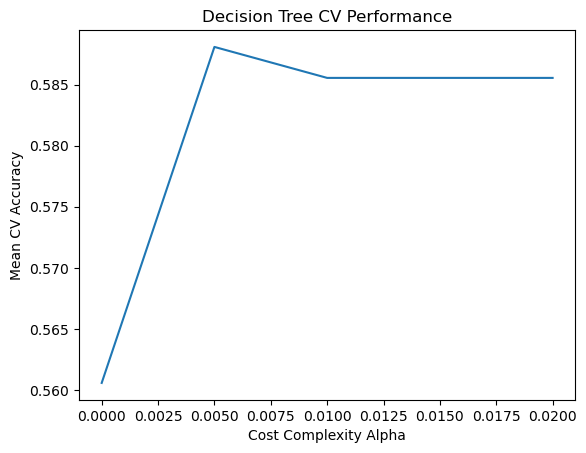

In [5]:
# Problem 2 - Decision Tree

ccp_alpha_vals = [0, 0.005, 0.010, 0.015, 0.020]

startTime = time.time()
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5104)
cv_means = []

for alpha in ccp_alpha_vals:
    dtc2 = DecisionTreeClassifier(criterion = 'gini', ccp_alpha=alpha, random_state=5104)
    scores = cross_val_score(dtc2, X2_train, y2_train, cv=kf, scoring='accuracy')
    # using accuracy instead of recall since we don't only have a positive and negative class anymore
    cv_means.append(np.mean(scores))
    print('for alpha value: ' + str(alpha)+', average accuracy metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was ccp_alpha = ' + str(ccp_alpha_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(ccp_alpha_vals, cv_means)
plt.xlabel('Cost Complexity Alpha')
plt.ylabel('Mean CV Accuracy')
plt.title('Decision Tree CV Performance')
plt.show()

folds done
for alpha value: 1e-05, average negative logloss metric measure value among the k=5 folds was -0.7875611154907682
for alpha value: 0.0001, average negative logloss metric measure value among the k=5 folds was -0.7872241091478253
for alpha value: 0.001, average negative logloss metric measure value among the k=5 folds was -0.7874629114577039
for alpha value: 0.01, average negative logloss metric measure value among the k=5 folds was -0.787898993828388
for alpha value: 0.1, average negative logloss metric measure value among the k=5 folds was -0.7872827672101579
[-0.7875611154907682, -0.7872241091478253, -0.7874629114577039, -0.787898993828388, -0.7872827672101579]
Best hyperparameter value was alpha = 0.0001 with performance metric value of -0.7872241091478253
Runtime: 309.42571902275085


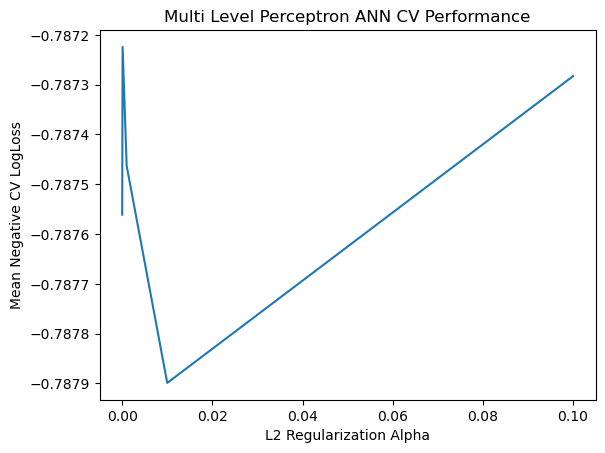

In [12]:
# Problem 2 - ANN

alpha_vals =  [0.00001, 0.0001, 0.001, 0.01, 0.1]
startTime = time.time()
kf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5103)
cv_means = []
print('folds done')

for alpha in alpha_vals:
    ann2 = MLPClassifier(activation = 'relu', alpha=alpha, random_state=5104, max_iter = 200)
    scores = cross_val_score(ann2, X2_train, y2_train, cv=kf, scoring='neg_log_loss')
    # using logloss/cross entropy loss as performance metric
    cv_means.append(np.mean(scores))
    print('for alpha value: ' + str(alpha)+', average negative logloss metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was alpha = ' + str(alpha_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(alpha_vals, cv_means)
plt.xlabel('L2 Regularization Alpha')
plt.ylabel('Mean Negative CV LogLoss')
plt.title('Multi Level Perceptron ANN CV Performance')
plt.show()

for smoothing alpha value: 0.0001, average accuracy metric measure value among the k=5 folds was 0.5133978070953888
for smoothing alpha value: 0.001, average accuracy metric measure value among the k=5 folds was 0.5133978070953888
for smoothing alpha value: 0.01, average accuracy metric measure value among the k=5 folds was 0.5133978070953888
for smoothing alpha value: 0.1, average accuracy metric measure value among the k=5 folds was 0.5133978070953888
for smoothing alpha value: 0.5, average accuracy metric measure value among the k=5 folds was 0.5133978070953888
for smoothing alpha value: 1, average accuracy metric measure value among the k=5 folds was 0.513378097321805
for smoothing alpha value: 5, average accuracy metric measure value among the k=5 folds was 0.5133189680010529
Best hyperparameter value was alpha = 0.0001 with performance metric value of 0.5133978070953888
Runtime: 2.4239771366119385


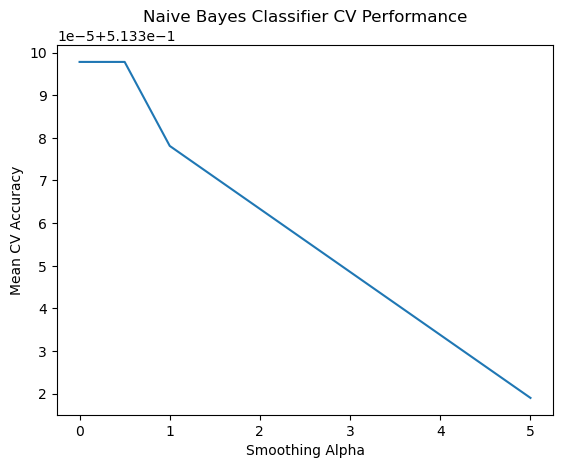

In [10]:
# Problem 2 - Naive Bayes Classifier

# remaining vars after dimension reduction: CholCheck  BMI  PhysActivity  GenHlth  PhysHlth  DiffWalk  Age  Income

smoothing_alpha_vals =  [0.0001, 0.001, 0.01, 0.1, 0.5, 1, 5]

binary_vars = ['CholCheck', 'PhysActivity', 'DiffWalk']

cat_vars = ['Age', 'GenHlth', 'Income']

num_vars = ['BMI', 'PhysHlth']

X2_train_cat = X2_train[cat_vars]
X2_train_num = X2_train[num_vars]
X2_train_bin = X2_train[binary_vars]

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5103)

cv_means = []
startTime = time.time()

for alpha in smoothing_alpha_vals:
    fold_scores = []
    
    for train_idx, test_idx in kf.split(X2_train, y2_train):

        # manually doing k folds bc idk how to use cross_val_score when combining results from 3 different estimators
        # split into separate training and test folds for cat, num and bin variables
        X_cat_tr = X2_train_cat.iloc[train_idx]
        X_cat_te = X2_train_cat.iloc[test_idx]
        
        X_num_tr = X2_train_num.iloc[train_idx]
        X_num_te = X2_train_num.iloc[test_idx]
        
        X_bin_tr = X2_train_bin.iloc[train_idx]
        X_bin_te = X2_train_bin.iloc[test_idx]
        
        y_tr = y2_train.iloc[train_idx]
        y_te = y2_train.iloc[test_idx]
        
        # models
        nbc = CategoricalNB(alpha=alpha)
        nbm = MultinomialNB(alpha=alpha)
        nbb = BernoulliNB(alpha=alpha)
        
        nbc.fit(X_cat_tr, y_tr)
        nbm.fit(X_num_tr, y_tr)
        nbb.fit(X_bin_tr, y_tr)
        
        # Use log probs in order to stop vals from getting to small at first
        log_prob_cat = nbc.predict_log_proba(X_cat_te)
        log_prob_num = nbm.predict_log_proba(X_num_te)
        log_prob_bin = nbb.predict_log_proba(X_bin_te)
        log_probs = log_prob_cat + log_prob_num + log_prob_bin

        # get performance metrics
        y_pred = np.argmax(log_probs, axis=1)
        acc = accuracy_score(y_te, y_pred)
        fold_scores.append(acc)
    
    mean_score = np.mean(fold_scores)
    cv_means.append(mean_score)
    
    print('for smoothing alpha value: ' + str(alpha)+', average accuracy metric measure value among the k=5 folds was '+str(mean_score))


endTime = time.time()
runTime = endTime - startTime

best_index = np.argmax(cv_means)

print('Best hyperparameter value was alpha = ' + str(smoothing_alpha_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(smoothing_alpha_vals, cv_means)
plt.xlabel('Smoothing Alpha')
plt.ylabel('Mean CV Accuracy')
plt.title('Naive Bayes Classifier CV Performance')
plt.show()

folds done
for number of trees: 25, average accuracy metric measure value among the k=5 folds was 0.5795638358170907
for number of trees: 50, average accuracy metric measure value among the k=5 folds was 0.581386996307887
for number of trees: 100, average accuracy metric measure value among the k=5 folds was 0.5832742206041174
for number of trees: 200, average accuracy metric measure value among the k=5 folds was 0.5840527606669335
for number of trees: 300, average accuracy metric measure value among the k=5 folds was 0.5848115910775669
[0.5795638358170907, 0.581386996307887, 0.5832742206041174, 0.5840527606669335, 0.5848115910775669]
Best hyperparameter value was number of trees = 300 with performance metric value of 0.5848115910775669
Runtime: 254.68423509597778


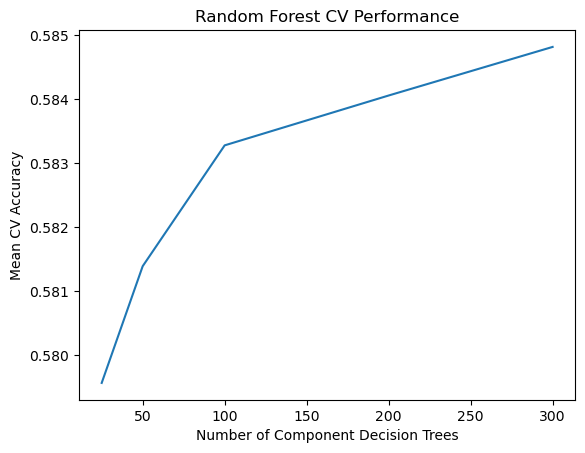

In [11]:
# Problem 2 - Random Forest

num_trees_vals = [25, 50, 100, 200, 300]
startTime = time.time()
kf = StratifiedKFold(n_splits=5, shuffle = True, random_state = 5103)
cv_means = []
print('folds done')

for tree_num in num_trees_vals:
    rfc2 = RandomForestClassifier(criterion = 'gini', n_estimators = tree_num)
    scores = cross_val_score(rfc2, X2_train, y2_train, cv=kf, scoring='accuracy')
    # using recall as performance metric (same reasoning as that for decision tree)
    cv_means.append(np.mean(scores))
    print('for number of trees: ' + str(tree_num)+', average accuracy metric measure value among the k=5 folds was '+str(np.mean(scores)))
endTime = time.time()
runTime = endTime-startTime
print(cv_means)
best_index = np.argmax(cv_means)
print('Best hyperparameter value was number of trees = ' + str(num_trees_vals[best_index]) + ' with performance metric value of ' + str(cv_means[best_index]))
print('Runtime: ' + str(runTime))
plt.plot(num_trees_vals, cv_means)
plt.xlabel('Number of Component Decision Trees')
plt.ylabel('Mean CV Accuracy')
plt.title('Random Forest CV Performance')
plt.show()

In [19]:
# Problem 2 - FINAL MODEL TRAINING/TESTING

best_ccp_alpha = 0.005

startTime = time.time()
print("DECISION TREE:")

dtc2 = DecisionTreeClassifier(criterion = 'gini', ccp_alpha=best_ccp_alpha, random_state=5104)
dtc2.fit(X2_train, y2_train)
y2_train_pred = dtc2.predict(X2_train)
train_acc = accuracy_score(y2_train_pred, y2_train)

endTime = time.time()
runTime = endTime-startTime
print("training runtime was "+str(runTime))
print("training performance was accuracy = "+str(train_acc))

startTime = time.time()
y2_val_pred = dtc2.predict(X2_val)
val_acc = accuracy_score(y2_val_pred, y2_val)
endTime = time.time()
runTime = endTime-startTime

print("testing runtime was "+str(runTime))
print("testing performance was accuracy = "+str(val_acc))

best_ann_alpha = 0.0001

startTime = time.time()
print("ANN:")

ann2 = MLPClassifier(activation = 'relu', alpha=best_ann_alpha, random_state=5104, max_iter = 200)
ann2.fit(X2_train, y2_train)
y2_train_proba = ann2.predict_proba(X2_train)
train_logloss = log_loss(y2_train, y2_train_proba)

endTime = time.time()
runTime = endTime-startTime
print("training runtime was "+str(runTime))
print("training performance was logloss = "+str(train_logloss))

startTime = time.time()
y2_val_proba = ann2.predict_proba(X2_val)
val_logloss = log_loss(y2_val, y2_val_proba)

endTime = time.time()
runTime = endTime-startTime
print("testing runtime was "+str(runTime))
print("testing performance was logloss = "+str(val_logloss))


best_smoothing_alpha = 0.0001

startTime = time.time()
print("Naive Bayes Classifier:")
# remaining vars after dimension reduction: CholCheck  BMI  PhysActivity  GenHlth  PhysHlth  DiffWalk  Age  Income

binary_vars = ['CholCheck', 'PhysActivity', 'DiffWalk']

cat_vars = ['Age', 'GenHlth', 'Income']

num_vars = ['BMI', 'PhysHlth']

X2_train_cat = X2_train[cat_vars]
X2_train_num = X2_train[num_vars]
X2_train_bin = X2_train[binary_vars]

nbc = CategoricalNB(alpha=best_smoothing_alpha)
nbm = MultinomialNB(alpha=best_smoothing_alpha)
nbb = BernoulliNB(alpha=best_smoothing_alpha)
        
nbc.fit(X2_train_cat, y2_train)
nbm.fit(X2_train_num, y2_train)
nbb.fit(X2_train_bin, y2_train)
        
# Use log probs in order to stop vals from getting to small at first
log_prob_cat = nbc.predict_log_proba(X2_train_cat)
log_prob_num = nbm.predict_log_proba(X2_train_num)
log_prob_bin = nbb.predict_log_proba(X2_train_bin)
log_probs = log_prob_cat + log_prob_num + log_prob_bin

# get performance metrics
y2_train_pred = np.argmax(log_probs, axis=1)
train_acc = accuracy_score(y2_train, y2_train_pred)

endTime = time.time()
runTime = endTime-startTime
print("training runtime was "+str(runTime))
print("training performance was accuracy = "+str(train_acc))

startTime = time.time()
# Use log probs in order to stop vals from getting to small at first
log_prob_cat = nbc.predict_log_proba(X2_val[cat_vars])
log_prob_num = nbm.predict_log_proba(X2_val[num_vars])
log_prob_bin = nbb.predict_log_proba(X2_val[binary_vars])
log_probs = log_prob_cat + log_prob_num + log_prob_bin

# get performance metrics
y2_val_pred = np.argmax(log_probs, axis=1)
val_acc = accuracy_score(y2_val_pred, y2_val)

endTime = time.time()
runTime = endTime-startTime
print("testing runtime was "+str(runTime))
print("testing performance was accuracy = "+str(val_acc))



best_num_trees = 300
startTime = time.time()
print("RANDOM FOREST:")

rfc2 = RandomForestClassifier(criterion = 'gini', n_estimators = best_num_trees)
rfc2.fit(X2_train, y2_train)
y2_train_pred = rfc2.predict(X2_train)
train_acc = accuracy_score(y2_train_pred, y2_train)

endTime = time.time()
runTime = endTime-startTime
print("training runtime was "+str(runTime))
print("training performance was accuracy = "+str(train_acc))

startTime = time.time()
y2_val_pred = rfc2.predict(X2_val)
val_acc = accuracy_score(y2_val_pred, y2_val)
endTime = time.time()
runTime = endTime-startTime

print("testing runtime was "+str(runTime))
print("testing performance was recall = "+str(val_acc))

DECISION TREE:
training runtime was 5.155625104904175
training performance was accuracy = 0.5904929438662883
testing runtime was 0.011291265487670898
testing performance was accuracy = 0.5902317880794702
ANN:
training runtime was 16.60906219482422
training performance was logloss = 0.7857269469382614
testing runtime was 0.03080892562866211
testing performance was logloss = 0.7847906792408647
Naive Bayes Classifier:
training runtime was 0.3820981979370117
training performance was accuracy = 0.5138018369599495
testing runtime was 0.01625204086303711
testing performance was accuracy = 0.5082387259539577
RANDOM FOREST:
training runtime was 34.42234992980957
training performance was accuracy = 0.7718434642068748
testing runtime was 3.0959858894348145
testing performance was recall = 0.5829982655313781
